# Performance journalière sur 12 mois — Comparaison par cohorte

## Objectif
Visualiser et comparer la **performance cumulée quotidienne** des IPO sur leurs **12 premiers mois de cotation**.

## Cohortes
- **2019-2020** : marché pré-Covid et choc pandémique
- **2021-2023** : période de hausse des taux et normalisation

## Méthodologie
1. Téléchargement des prix quotidiens via `yfinance` (avec cache local)
2. Calcul du rendement cumulé : `(Prix_j / Prix_ouverture_IPO) - 1`
3. Alignement sur le **jour de trading** (J=1, 2, ..., 252)
4. Agrégation par cohorte : médiane, moyenne, IQR
5. Visualisation comparative

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
import os
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (14, 6), "figure.dpi": 120})

COLORS = {"2019-2020": "#2C7BB6", "2021-2023": "#D7191C"}
CACHE_PATH = Path("data/daily_returns_cache.csv")
N_TRADING_DAYS = 365  # ~12 mois

print("Imports OK")

Imports OK


In [4]:
# ── 1. Chargement des données de base ──────────────────────────────────────
df_base = pd.read_excel("data/dataset_complet_filled.xlsx")
df_base["ipo_date"] = pd.to_datetime(df_base["ipo_date"])

df_base = df_base[df_base["year"].between(2019, 2024)].copy()
df_base = df_base.dropna(subset=["ipo_date", "open_px"])
df_base = df_base[df_base["open_px"] > 0].copy()

# Attribution des cohortes
df_base["cohort"] = np.where(df_base["year"].between(2019, 2021), "2019-2021", "2022-2024")

print(f"Total IPOs retenus : {len(df_base)}")
print(df_base.groupby(["year", "cohort"]).size().to_string())

Total IPOs retenus : 782
year  cohort   
2019  2019-2021    112
2020  2019-2021    143
2021  2019-2021    163
2022  2022-2024     69
2023  2022-2024     98
2024  2022-2024    197


In [5]:
# ── 2. Téléchargement des prix quotidiens (avec cache) ─────────────────────
# Le cache évite de re-télécharger à chaque exécution (~5-10 min la 1ère fois)


if CACHE_PATH.exists():
    print(f"✓ Cache trouvé : {CACHE_PATH}")
    df_daily = pd.read_csv(CACHE_PATH)
    print(f"  {len(df_daily):,} lignes | {df_daily['ticker'].nunique()} tickers")
else:
    print("Téléchargement des données quotidiennes (première exécution)...")
    print(f"Nombre de tickers à traiter : {len(df_base)}")
    print("Cela peut prendre 5-15 minutes...\n")

    records = []
    errors = []

    for i, row in df_base.iterrows():
        ticker    = row["ticker"]
        ipo_date  = row["ipo_date"]
        cohort    = row["cohort"]
        year      = row["year"]
        open_px   = row["open_px"]

        # Fenêtre : IPO date → IPO date + 14 mois (buffer)
        end_date = ipo_date + pd.DateOffset(days=430)

        try:
            hist = yf.download(
                ticker,
                start=ipo_date.strftime("%Y-%m-%d"),
                end=end_date.strftime("%Y-%m-%d"),
                progress=False,
                auto_adjust=True,
            )

            if hist.empty or len(hist) < 20:
                errors.append((ticker, "données insuffisantes"))
                continue

            # Aplatir les colonnes multi-index si nécessaire
            if isinstance(hist.columns, pd.MultiIndex):
                hist.columns = [col[0] for col in hist.columns]

            # Garder seulement les N_TRADING_DAYS premiers jours
            hist = hist.head(N_TRADING_DAYS).reset_index()
            hist["trading_day"] = range(1, len(hist) + 1)

            # Rendement cumulé par rapport au prix d'ouverture de l'IPO
            hist["cum_return"] = hist["Close"] / open_px - 1

            for _, h in hist.iterrows():
                records.append({
                    "ticker":       ticker,
                    "cohort":       cohort,
                    "year":         year,
                    "date":         h["Date"],
                    "trading_day":  int(h["trading_day"]),
                    "close":        float(h["Close"]),
                    "cum_return":   float(h["cum_return"]),
                })

        except Exception as e:
            errors.append((ticker, str(e)))

        # Affichage progression
        idx = list(df_base.index).index(i)
        if (idx + 1) % 50 == 0:
            print(f"  {idx + 1}/{len(df_base)} tickers traités...")

    df_daily = pd.DataFrame(records)

    # Sauvegarde du cache
    df_daily.to_csv(CACHE_PATH, index=False)
    print(f"\n✓ Cache sauvegardé : {CACHE_PATH}")
    print(f"  {len(df_daily):,} lignes | {df_daily['ticker'].nunique()} tickers OK")
    if errors:
        print(f"  {len(errors)} tickers échoués : {[e[0] for e in errors[:10]]}...")

print(df_daily.head())

✓ Cache trouvé : data\daily_returns_cache.parquet
  152,460 lignes | 605 tickers
  ticker     cohort  year       date  trading_day      close  cum_return
0   PINS  2019-2020  2019 2019-04-18            1  24.400000    0.027368
1   PINS  2019-2020  2019 2019-04-22            2  24.990000    0.052211
2   PINS  2019-2020  2019 2019-04-23            3  25.850000    0.088421
3   PINS  2019-2020  2019 2019-04-24            4  26.799999    0.128421
4   PINS  2019-2020  2019 2019-04-25            5  28.799999    0.212632


In [6]:
# ── 3. Construction du DataFrame agrégé ───────────────────────────────────
# Pour chaque (cohorte, jour de trading) : médiane, moyenne, Q1, Q3, nombre d'IPOs

def cohort_agg(df):
    return df.groupby(["cohort", "trading_day"])["cum_return"].agg(
        n_ipo="count",
        mean="mean",
        median="median",
        q10=lambda x: np.quantile(x, 0.10),
        q25=lambda x: np.quantile(x, 0.25),
        q75=lambda x: np.quantile(x, 0.75),
        q90=lambda x: np.quantile(x, 0.90),
        std="std",
    ).reset_index()

agg = cohort_agg(df_daily)

# Affichage résumé
print("=== DataFrame agrégé ===")
print(agg.head(10).to_string())
print(f"\nShape : {agg.shape}")
print(f"\nNombre d'IPOs par cohorte à J=1 :")
print(agg[agg["trading_day"] == 1][["cohort", "n_ipo"]].to_string(index=False))
print(f"\nNombre d'IPOs par cohorte à J=252 :")
print(agg[agg["trading_day"] == 252][["cohort", "n_ipo"]].to_string(index=False))

=== DataFrame agrégé ===
      cohort  trading_day  n_ipo      mean    median       q10       q25       q75       q90       std
0  2019-2020            1    259  0.063939  0.000000 -0.130345 -0.061731  0.072634  0.248415  0.461953
1  2019-2020            2    259  0.091281  0.005747 -0.152858 -0.066037  0.100264  0.283085  0.578767
2  2019-2020            3    259  0.127884  0.009174 -0.164550 -0.081119  0.113550  0.311841  0.985609
3  2019-2020            4    259  0.108001  0.007258 -0.181546 -0.079742  0.125157  0.302471  0.693607
4  2019-2020            5    259  0.102279  0.011166 -0.169668 -0.075683  0.159010  0.309311  0.544438
5  2019-2020            6    259  0.101847  0.015427 -0.185482 -0.084596  0.161147  0.345641  0.520152
6  2019-2020            7    259  0.101605  0.014815 -0.185999 -0.086235  0.147133  0.350499  0.589681
7  2019-2020            8    259  0.099555  0.012857 -0.187237 -0.085673  0.141243  0.356594  0.553391
8  2019-2020            9    259  0.100842  0.02

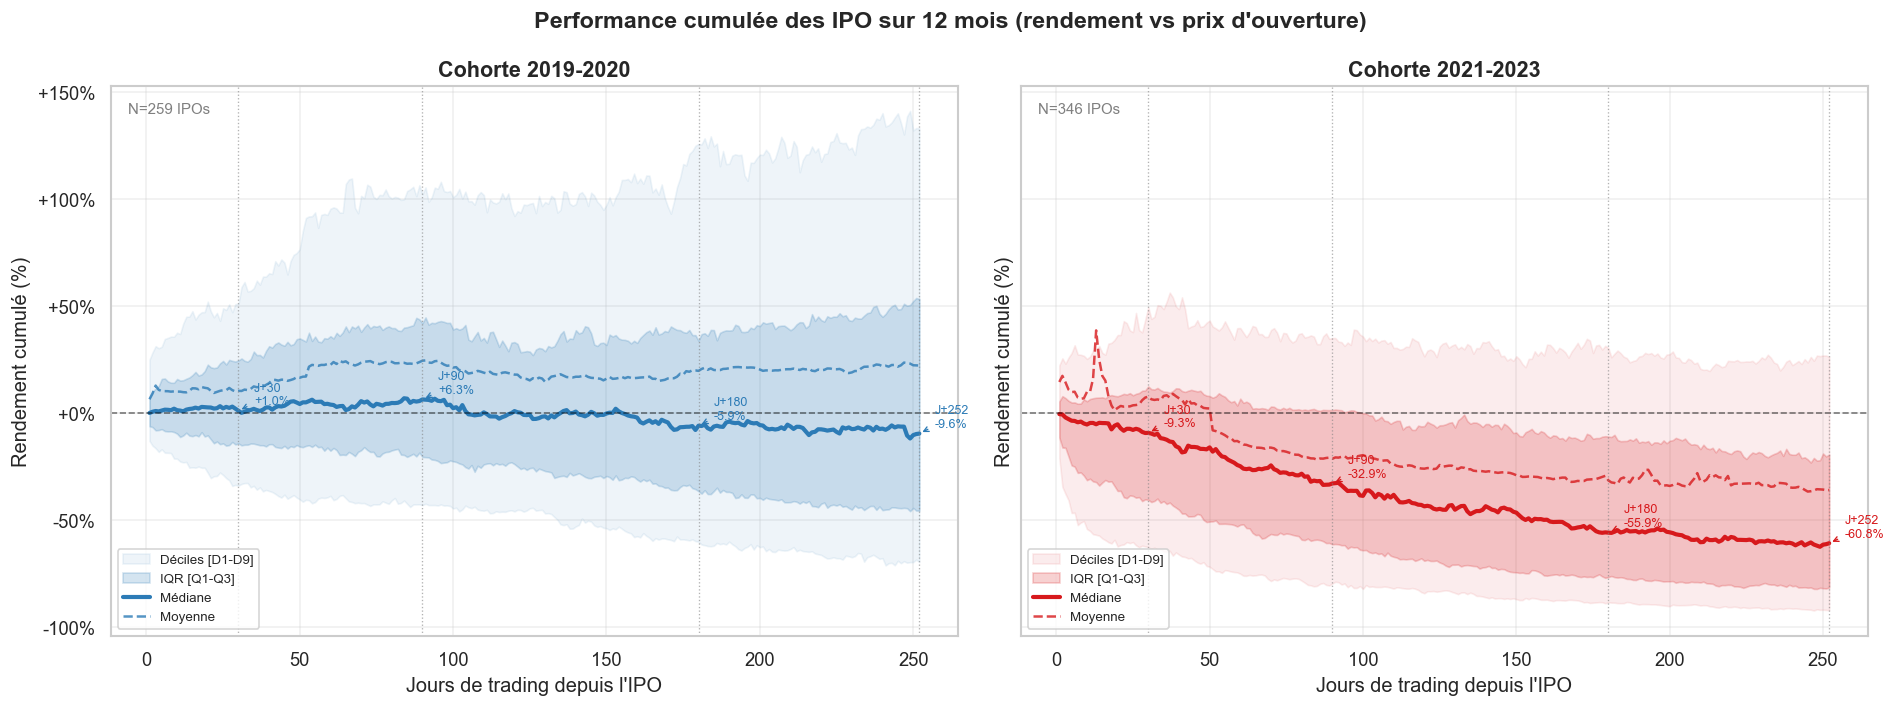

In [7]:
# ── 4. Graphique 1 : Vue comparative côte à côte ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, cohort in zip(axes, ["2019-2020", "2021-2023"]):
    sub = agg[agg["cohort"] == cohort].copy()
    col = COLORS[cohort]

    # Bande Q10-Q90
    ax.fill_between(
        sub["trading_day"],
        sub["q10"] * 100,
        sub["q90"] * 100,
        color=col, alpha=0.08, label="Déciles [D1-D9]"
    )
    # Bande IQR Q25-Q75
    ax.fill_between(
        sub["trading_day"],
        sub["q25"] * 100,
        sub["q75"] * 100,
        color=col, alpha=0.20, label="IQR [Q1-Q3]"
    )
    # Médiane
    ax.plot(sub["trading_day"], sub["median"] * 100,
            color=col, lw=2.5, label="Médiane")
    # Moyenne (pointillé)
    ax.plot(sub["trading_day"], sub["mean"] * 100,
            color=col, lw=1.5, ls="--", alpha=0.8, label="Moyenne")

    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax.set_title(f"Cohorte {cohort}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Jours de trading depuis l'IPO")
    ax.set_ylabel("Rendement cumulé (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))

    # Annotations J=30, J=90, J=180, J=252
    for day, label in [(30, "J+30"), (90, "J+90"), (180, "J+180"), (252, "J+252")]:
        point = sub[sub["trading_day"] == day]
        if not point.empty:
            med_val = point["median"].values[0] * 100
            ax.axvline(day, color="gray", lw=0.8, ls=":", alpha=0.6)
            ax.annotate(f"{label}\n{med_val:+.1f}%",
                        xy=(day, med_val),
                        xytext=(day + 5, med_val + 3),
                        fontsize=7.5, color=col,
                        arrowprops=dict(arrowstyle="->", color=col, lw=0.8))

    n_start = sub[sub["trading_day"] == 1]["n_ipo"].values
    n_end   = sub[sub["trading_day"] == sub["trading_day"].max()]["n_ipo"].values
    n_start = n_start[0] if len(n_start) else "?"
    n_end   = n_end[0]   if len(n_end)   else "?"
    ax.text(0.02, 0.97, f"N={n_start} IPOs",
            transform=ax.transAxes, va="top", fontsize=9,
            color="gray")
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Performance cumulée des IPO sur 12 mois (rendement vs prix d'ouverture)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("data/perf_12m_par_cohorte.png", dpi=150, bbox_inches="tight")
plt.show()

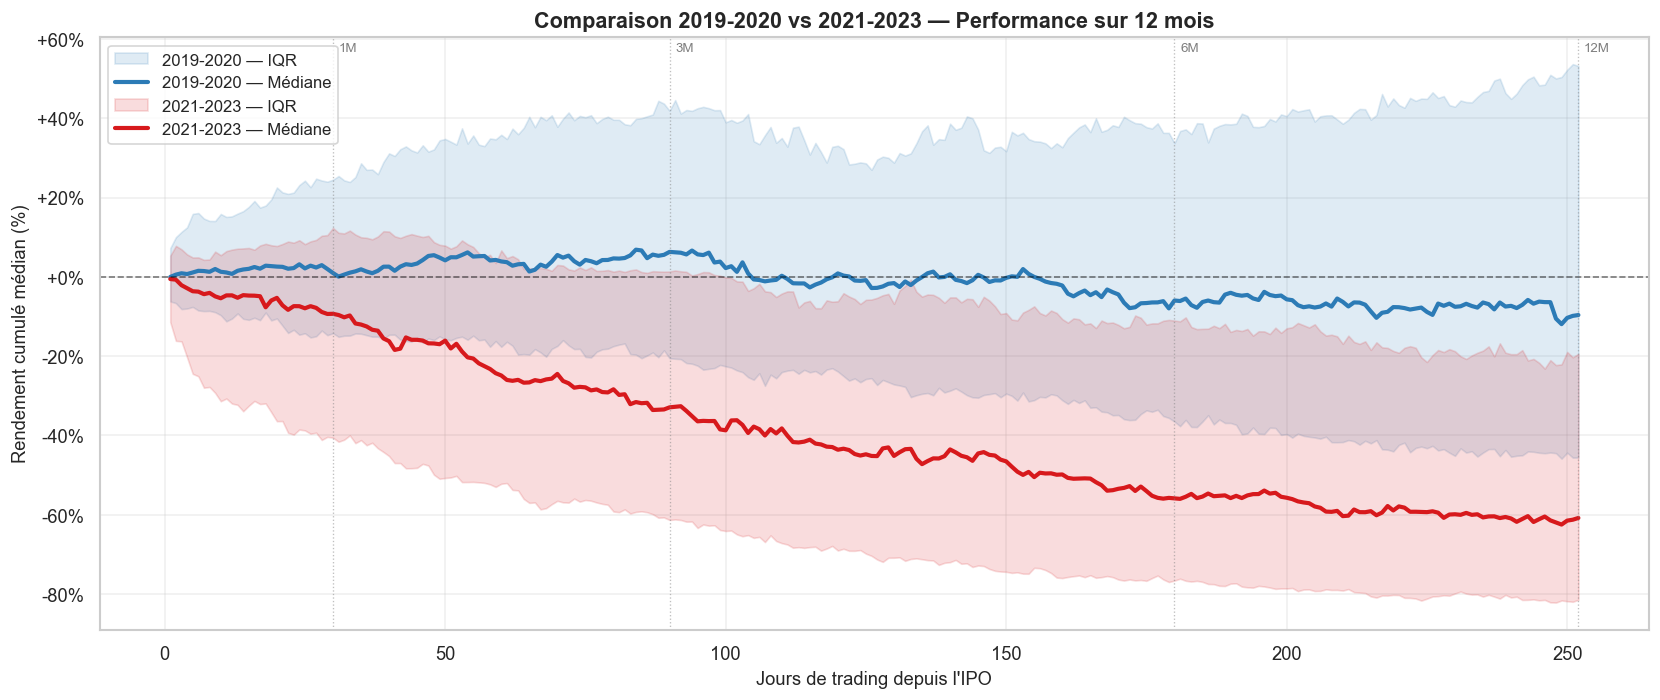

In [8]:
# ── 5. Graphique 2 : Comparaison directe sur un seul axe ─────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for cohort in ["2019-2020", "2021-2023"]:
    sub = agg[agg["cohort"] == cohort].copy()
    col = COLORS[cohort]

    ax.fill_between(
        sub["trading_day"],
        sub["q25"] * 100,
        sub["q75"] * 100,
        color=col, alpha=0.15, label=f"{cohort} — IQR"
    )
    ax.plot(sub["trading_day"], sub["median"] * 100,
            color=col, lw=2.5, label=f"{cohort} — Médiane")

ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)

# Lignes verticales milestones
for day, label in [(30, "1M"), (90, "3M"), (180, "6M"), (252, "12M")]:
    ax.axvline(day, color="gray", lw=0.8, ls=":", alpha=0.5)
    ax.text(day + 1, ax.get_ylim()[1] * 0.98 if ax.get_ylim() else 5,
            label, fontsize=8, color="gray", va="top")

ax.set_xlabel("Jours de trading depuis l'IPO", fontsize=11)
ax.set_ylabel("Rendement cumulé médian (%)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
ax.set_title(
    "Comparaison 2019-2020 vs 2021-2023 — Performance sur 12 mois",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/perf_12m_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

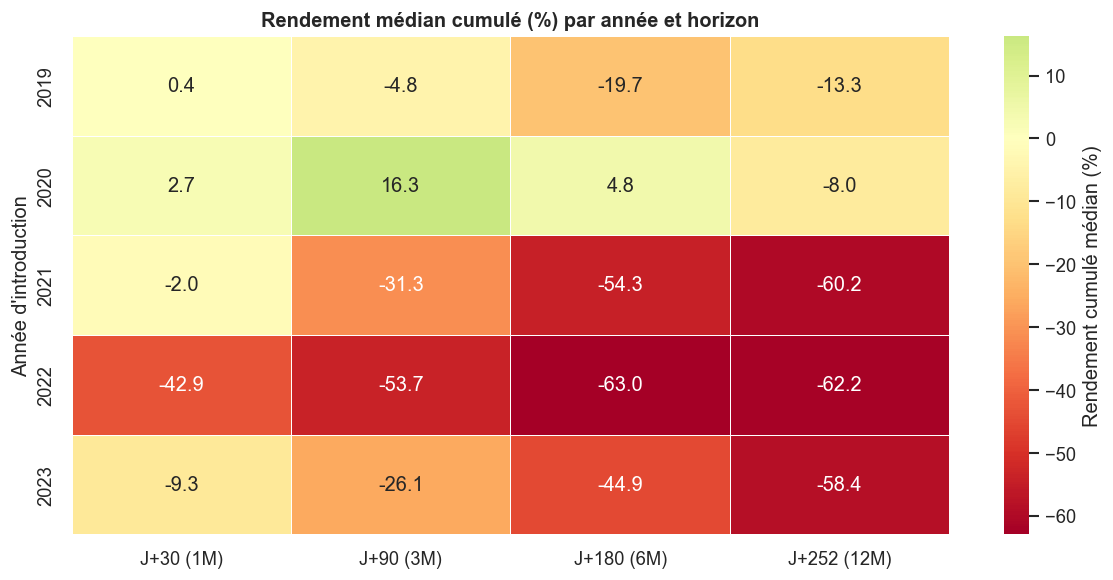


=== Tableau complet des rendements médians ===
Horizon  J+30 (1M)  J+90 (3M)  J+180 (6M)  J+252 (12M)
Année                                                 
2019         +0.4%      -4.8%      -19.7%       -13.3%
2020         +2.7%     +16.3%       +4.8%        -8.0%
2021         -2.0%     -31.3%      -54.3%       -60.2%
2022        -42.9%     -53.7%      -63.0%       -62.2%
2023         -9.3%     -26.1%      -44.9%       -58.4%


In [9]:
# ── 6. Graphique 3 : Heatmap par année et mois de trading ─────────────────
# Rendement médian par année d'IPO à J=30, J=90, J=180, J=252

milestones = [30, 90, 180, 252]
labels = ["J+30 (1M)", "J+90 (3M)", "J+180 (6M)", "J+252 (12M)"]

rows = []
for year in sorted(df_daily["year"].unique()):
    for day, lbl in zip(milestones, labels):
        sub = df_daily[(df_daily["year"] == year) & (df_daily["trading_day"] == day)]
        if len(sub) > 0:
            rows.append({"Année": year, "Horizon": lbl,
                         "Médiane (%)": sub["cum_return"].median() * 100,
                         "N IPOs":      len(sub)})

df_heat = pd.DataFrame(rows)
pivot = df_heat.pivot(index="Année", columns="Horizon", values="Médiane (%)")
pivot = pivot[["J+30 (1M)", "J+90 (3M)", "J+180 (6M)", "J+252 (12M)"]]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Rendement cumulé médian (%)"},
    ax=ax
)
ax.set_title("Rendement médian cumulé (%) par année et horizon",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Année d'introduction")
plt.tight_layout()
plt.savefig("data/perf_heatmap_annee.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Tableau complet des rendements médians ===")
print(pivot.to_string(float_format=lambda x: f"{x:+.1f}%"))

In [10]:
# ── 7. Table de synthèse finale ────────────────────────────────────────────
print("=" * 65)
print("SYNTHÈSE — Rendements médians aux horizons clés")
print("=" * 65)

for cohort in ["2019-2020", "2021-2023"]:
    sub = agg[agg["cohort"] == cohort]
    print(f"\nCohorte {cohort} :")
    print(f"  {'Horizon':<12} {'Médiane':>10} {'Moyenne':>10} {'Q25':>10} {'Q75':>10} {'N':>6}")
    print(f"  {'-'*60}")
    for day, lbl in zip([30, 90, 180, 252], ["J+30 (1M)", "J+90 (3M)", "J+180 (6M)", "J+252 (12M)"]):
        row = sub[sub["trading_day"] == day]
        if not row.empty:
            r = row.iloc[0]
            print(f"  {lbl:<12} {r['median']*100:>+9.1f}% {r['mean']*100:>+9.1f}% "
                  f"{r['q25']*100:>+9.1f}% {r['q75']*100:>+9.1f}% {int(r['n_ipo']):>6}")

print("\n" + "=" * 65)

SYNTHÈSE — Rendements médians aux horizons clés

Cohorte 2019-2020 :
  Horizon         Médiane    Moyenne        Q25        Q75      N
  ------------------------------------------------------------
  J+30 (1M)         +1.0%     +10.3%     -14.2%     +24.5%    259
  J+90 (3M)         +6.3%     +24.4%     -20.5%     +41.9%    259
  J+180 (6M)        -5.9%     +19.7%     -36.5%     +33.8%    259
  J+252 (12M)       -9.6%     +22.2%     -45.6%     +53.2%    259

Cohorte 2021-2023 :
  Horizon         Médiane    Moyenne        Q25        Q75      N
  ------------------------------------------------------------
  J+30 (1M)         -9.3%      +7.7%     -40.6%     +12.4%    346
  J+90 (3M)        -32.9%     -21.4%     -61.3%      +1.4%    346
  J+180 (6M)       -55.9%     -31.5%     -76.6%     -11.0%    346
  J+252 (12M)      -60.8%     -36.0%     -81.4%     -19.4%    346

